<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-airnav/blob/main/NYC_Boston_Chicago_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: Install Compatible h3 and Required Libraries
!pip install h3==3.7.6
!pip install geopandas matplotlib seaborn scikit-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.1 MB/s eta 0:00:00


In [2]:
# STEP 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h3
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.cluster import KMeans
import statsmodels.api as sm
from google.colab import files

#NYC Datasets

In [ ]:
# STEP 3: Upload Files
print("Upload: NYC_PM.csv, NYC_PM_Part1.csv, NYC_PM_Part2.csv, NYC_PM_Part3.csv, NYC_AQ.csv")
uploaded = files.upload()

Upload: NYC_PM.csv, NYC_PM_Part1.csv, NYC_PM_Part2.csv, NYC_PM_Part3.csv, NYC_AQ.csv


Saving NYC_PM.csv to NYC_PM.csv
Saving NYC_PM_Part3.csv to NYC_PM_Part3.csv
Saving NYC_PM_Part2.csv to NYC_PM_Part2.csv
Saving NYC_PM_Part1.csv to NYC_PM_Part1.csv
Saving NYC_AQ.csv to NYC_AQ.csv


In [ ]:
# STEP 4: Load and Merge PM Data
pm_main = pd.read_csv("NYC_PM.csv")
pm_parts = [pd.read_csv(f) for f in ["NYC_PM_Part1.csv", "NYC_PM_Part2.csv", "NYC_PM_Part3.csv"]]
pm_all = pd.concat([pm_main] + pm_parts, ignore_index=True)

In [ ]:
# STEP 5: Load AQ and Convert Time
aq = pd.read_csv("NYC_AQ.csv")
pm_all["datetime"] = pd.to_datetime(pm_all["time"], unit="s")
aq["datetime"] = pd.to_datetime(aq["time"], unit="s")

In [ ]:
# STEP 6: Merge Datasets
merged = pd.merge(pm_all, aq, on=["SensorID", "datetime"], suffixes=("_pm", "_aq"))

In [ ]:
# STEP 7: H3 Geohash Encoding
def latlon_to_h3(row, resolution=9):
    return h3.geo_to_h3(row["latitude_pm"], row["longitude_pm"], resolution)

merged["h3"] = merged.apply(latlon_to_h3, axis=1)

In [ ]:
# STEP 8: Normalize Features
scaler = StandardScaler()
merged[["pm25_pm_norm", "pm10_norm"]] = scaler.fit_transform(merged[["pm25_pm", "pm10"]].fillna(0))

In [ ]:
# STEP 9: Aggregate by H3 Cell
agg_by_h3 = merged.groupby("h3").agg({
    "pm25_pm": ["mean", "std"],
    "pm10": ["mean", "std"],
    "temperature_pm": "mean",
    "humidity_pm": "mean",
    "SensorID": "count"
}).reset_index()
agg_by_h3.columns = ['h3', 'pm25_mean', 'pm25_std', 'pm10_mean', 'pm10_std', 'temp_mean', 'humidity_mean', 'samples']

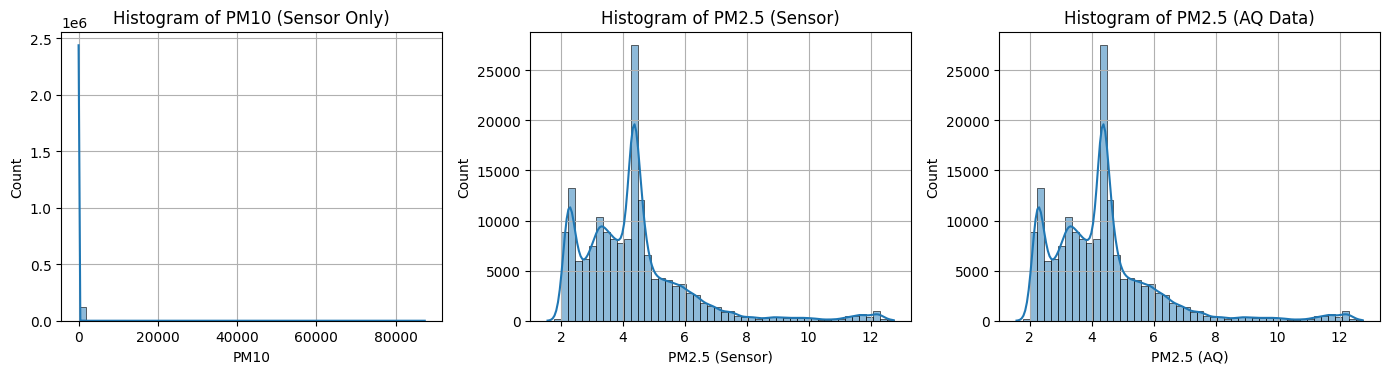

In [ ]:
# STEP 10: EDA - Histograms (using PM data only for PM10)

plt.figure(figsize=(14, 4))

# PM10 (from PM sensor only)
plt.subplot(1, 3, 1)
sns.histplot(pm_all["pm10"].dropna(), bins=50, kde=True)
plt.title("Histogram of PM10 (Sensor Only)")
plt.xlabel("PM10")
plt.grid(True)

# PM2.5 from PM sensor
plt.subplot(1, 3, 2)
sns.histplot(merged["pm25_pm"].dropna(), bins=50, kde=True)
plt.title("Histogram of PM2.5 (Sensor)")
plt.xlabel("PM2.5 (Sensor)")
plt.grid(True)

# PM2.5 from AQ source
plt.subplot(1, 3, 3)
sns.histplot(merged["pm25_aq"].dropna(), bins=50, kde=True)
plt.title("Histogram of PM2.5 (AQ Data)")
plt.xlabel("PM2.5 (AQ)")
plt.grid(True)

plt.tight_layout()
plt.show()

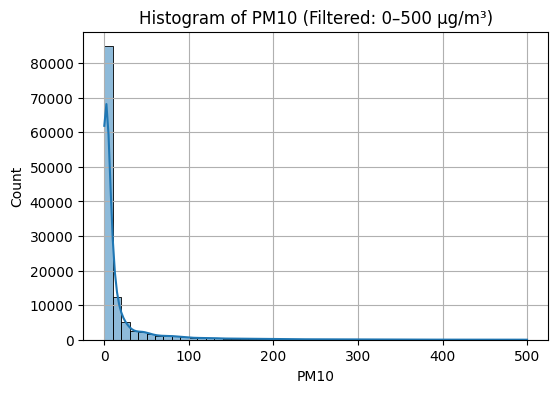

In [ ]:
plt.figure(figsize=(6, 4))
filtered_pm10 = pm_all["pm10"].dropna()
filtered_pm10 = filtered_pm10[(filtered_pm10 >= 0) & (filtered_pm10 <= 500)]  # Adjust if needed

sns.histplot(filtered_pm10, bins=50, kde=True)
plt.title("Histogram of PM10 (Filtered: 0–500 µg/m³)")
plt.xlabel("PM10")
plt.grid(True)
plt.show()

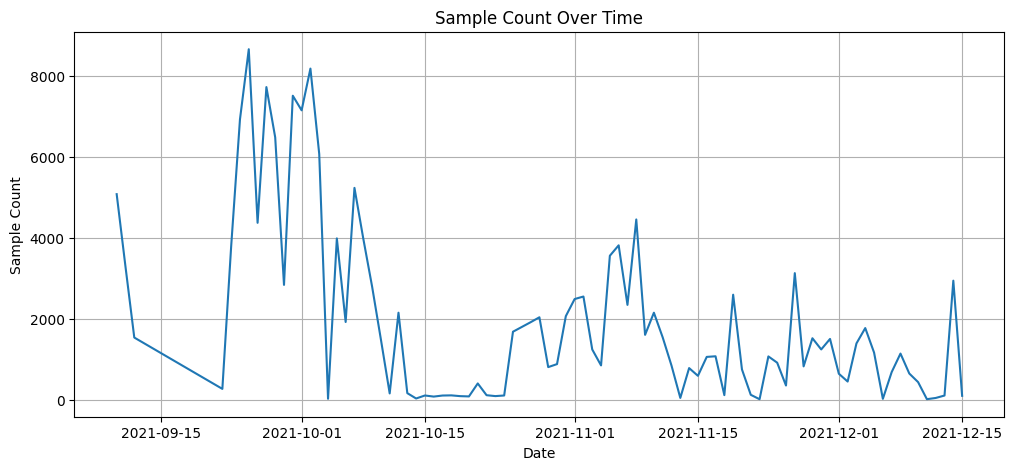

In [ ]:
# STEP 11: Time vs Sample Count
sample_over_time = merged.groupby(merged['datetime'].dt.date).size()

plt.figure(figsize=(12, 5))
sample_over_time.plot()
plt.title("Sample Count Over Time")
plt.xlabel("Date")
plt.ylabel("Sample Count")
plt.grid(True)
plt.show()

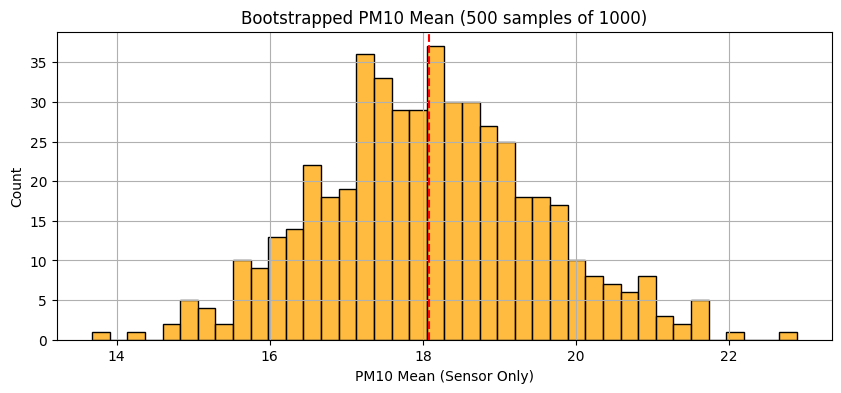

In [ ]:
# STEP 12: Bootstrapping Mean PM10 (from pm_all, filtered)
boot_means = [
    resample(
        pm_all["pm10"][(pm_all["pm10"] >= 0) & (pm_all["pm10"] <= 500)].dropna(),
        n_samples=1000
    ).mean()
    for _ in range(500)
]

plt.figure(figsize=(10, 4))
sns.histplot(boot_means, bins=40, color='orange')
plt.axvline(np.mean(boot_means), color='red', linestyle='--')
plt.title("Bootstrapped PM10 Mean (500 samples of 1000)")
plt.xlabel("PM10 Mean (Sensor Only)")
plt.grid(True)
plt.show()

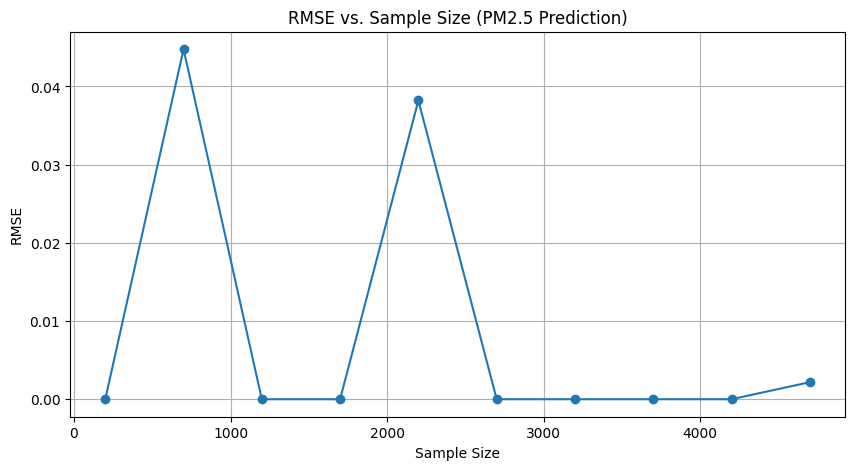

In [ ]:
# STEP 13: RMSE vs. Sample Size (PM2.5 Prediction)
samples = list(range(200, min(5000, len(merged)), 500))
rmses = []

for size in samples:
    sample = merged.sample(n=size)
    X = sample[["pm25_pm"]].fillna(0)
    y = sample["pm25_aq"].fillna(0)
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    rmses.append(rmse)

plt.figure(figsize=(10, 5))
plt.plot(samples, rmses, marker='o')
plt.title("RMSE vs. Sample Size (PM2.5 Prediction)")
plt.xlabel("Sample Size")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

In [ ]:
# STEP 14: Summary Statistics
summary_stats = merged[["pm25_pm", "pm25_aq"]].describe().T[["mean", "std", "min", "max"]]
summary_stats.loc["pm10_sensor"] = pm_all["pm10"][(pm_all["pm10"] >= 0) & (pm_all["pm10"] <= 500)].describe()[["mean", "std", "min", "max"]]

print("Summary Statistics:")
display(summary_stats)

Summary Statistics:


,mean,std,min,max
pm25_pm,4.310790,1.794630,1.568473,12.744419
pm25_aq,4.310790,1.794630,1.568473,12.744419
pm10_sensor,18.069142,45.071864,0.000000,499.650000


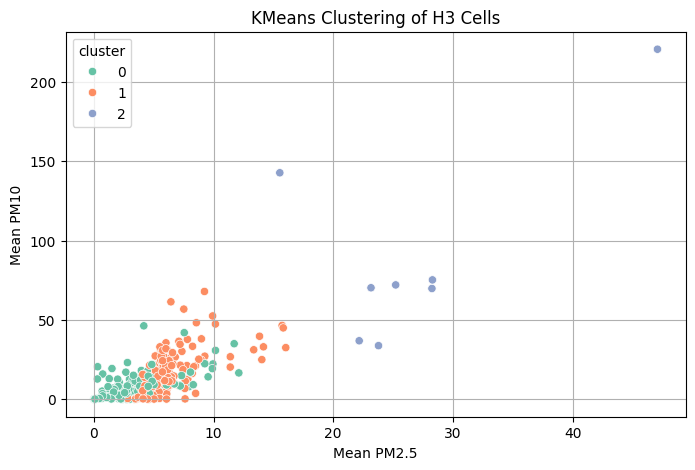

Cluster Profiles:


,pm25_mean,pm10_mean,temp_mean,humidity_mean,cluster
0,2.480485,5.268230,8.810725,54.818706,0
1,6.252662,16.854878,17.158615,54.079573,1
2,26.686068,90.179471,10.419346,77.511653,2


In [ ]:
# STEP 15: KMeans Clustering (on valid PM sensor data only)

# Recalculate H3 on pm_all to ensure consistency
pm_all["h3"] = pm_all.apply(lambda row: h3.geo_to_h3(row["latitude"], row["longitude"], 9), axis=1)

# Aggregate by H3 using only valid PM10 range
agg_by_h3 = pm_all.groupby("h3").agg({
    "pm25": "mean",  # Use "pm25_pm" if needed instead
    "pm10": lambda x: x[(x >= 0) & (x <= 500)].mean(),
    "temperature": "mean",
    "humidity": "mean"
}).reset_index()

agg_by_h3.columns = ["h3", "pm25_mean", "pm10_mean", "temp_mean", "humidity_mean"]

# Filter out NaNs before clustering
features = ["pm25_mean", "pm10_mean", "temp_mean", "humidity_mean"]
X = agg_by_h3[features].dropna().reset_index(drop=True)
X_scaled = StandardScaler().fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Create clustered DataFrame
agg_clustered = agg_by_h3.dropna(subset=features).reset_index(drop=True)
agg_clustered["cluster"] = cluster_labels

# Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=agg_clustered, x="pm25_mean", y="pm10_mean", hue="cluster", palette="Set2")
plt.title("KMeans Clustering of H3 Cells")
plt.xlabel("Mean PM2.5")
plt.ylabel("Mean PM10")
plt.grid(True)
plt.show()

# Show cluster centers
cluster_centers = pd.DataFrame(StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_), columns=features)
cluster_centers["cluster"] = range(3)
print("Cluster Profiles:")
display(cluster_centers)

In [ ]:
# STEP 16: Multivariate Regression
df = pm_all[["pm10", "pm25", "temperature", "humidity"]].dropna()
df = df[(df["pm10"] >= 0) & (df["pm10"] <= 500)]

X_reg = sm.add_constant(df[["pm25", "temperature", "humidity"]])
y_reg = df["pm10"]

model = sm.OLS(y_reg, X_reg).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   pm10   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                 1.870e+04
Date:                Sun, 04 May 2025   Prob (F-statistic):               0.00
Time:                        10:49:11   Log-Likelihood:            -5.9520e+05
No. Observations:              118258   AIC:                         1.190e+06
Df Residuals:                  118254   BIC:                         1.190e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           8.8475      0.288     30.713      

In [ ]:
# STEP 17: Save for Comparison
summary_stats = df.describe()[["pm25", "pm10"]].T[["mean", "std", "min", "max"]]
summary_stats["city"] = "NYC"
agg_clustered["city"] = "NYC"

summary_stats.to_csv("nyc_summary_stats.csv", index=True)
agg_clustered.to_csv("nyc_aggregated_h3.csv", index=False)

print(" NYC analysis complete and saved.")

 NYC analysis complete and saved.



# Chicago Datasets



In [ ]:
# STEP 18: Upload Chicago Datasets Files
print("Upload: chicago_eclipse_data_part_1.csv, chicago_eclipse_data_part_2.csv, chicago_eclipse_data_part_3.csv, chicago_eclipse_data_part_4.csv, chicago_eclipse_data_part_5.csv")
uploaded = files.upload()

Upload: chicago_eclipse_data_part_1.csv, chicago_eclipse_data_part_2.csv, chicago_eclipse_data_part_3.csv, chicago_eclipse_data_part_4.csv, chicago_eclipse_data_part_5.csv


Saving chicago_eclipse_data_part_5.csv to chicago_eclipse_data_part_5.csv
Saving chicago_eclipse_data_part_4.csv to chicago_eclipse_data_part_4.csv
Saving chicago_eclipse_data_part_3.csv to chicago_eclipse_data_part_3.csv
Saving chicago_eclipse_data_part_2.csv to chicago_eclipse_data_part_2.csv
Saving chicago_eclipse_data_part_1.csv to chicago_eclipse_data_part_1.csv


In [ ]:
# STEP 19: Load and Merge Data
data_parts = [pd.read_csv(f) for f in ["chicago_eclipse_data_part_1.csv", "chicago_eclipse_data_part_2.csv", "chicago_eclipse_data_part_3.csv", "chicago_eclipse_data_part_4.csv", "chicago_eclipse_data_part_5.csv"]]
data_all = pd.concat(pm_parts, ignore_index=True)

In [ ]:
# STEP 20: Convert Time
data_all["ReadingDateTimeUTC"] = pd.to_datetime(data_all["ReadingDateTimeUTC"])

In [ ]:
# STEP 21: H3 Geohash Encoding
def latlon_to_h3(row, resolution=9):
    return h3.geo_to_h3(row["Latitude"], row["Longitude"], resolution)

data_all["h3"] = data_all.apply(latlon_to_h3, axis=1)

In [ ]:
# STEP 22: Normalize Features
scaler = StandardScaler()
data_all[["pm25_norm" , "CalibratedPM25_norm"]] = scaler.fit_transform(data_all[["PM25", "CalibratedPM25"]].fillna(0))

In [ ]:
# STEP 23: Aggregate by H3 Cell
agg_by_h3 = data_all.groupby("h3").agg({
    "PM25": ["mean", "std"],
    "CalibratedPM25": ["mean", "std"],
    "CalibratedO3": "mean",
    "CalibratedNO2": "mean",
    "CO": "mean",
    "BatteryLevel": "mean",
    "Temperature": "mean",
    "Humidity": "mean",
    "CellSignal": "mean",
    "DeviceId": "count"
}).reset_index()
agg_by_h3.columns = ['h3', 'pm25_mean', 'pm25_std', 'calibratedPM25_mean', 'calibratedPM25_std', 'calibratedO3_mean', 'calibratedNO2_mean', 'co_mean', 'batteryLevel_mean', 'temp_mean', 'humidity_mean', 'cellSignal_mean', 'samples']

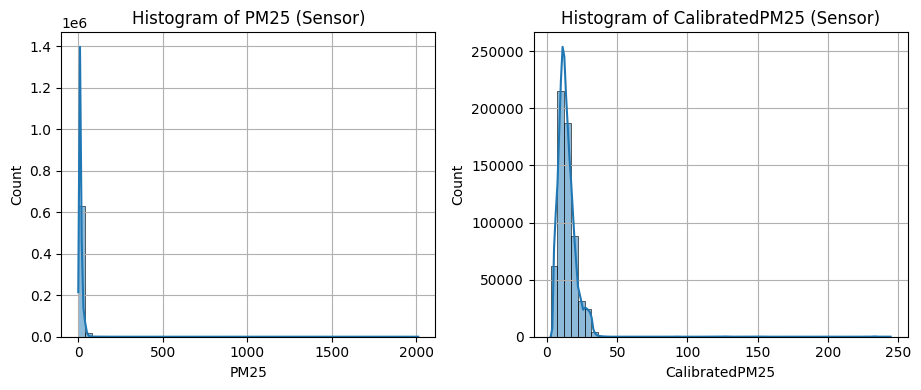

In [ ]:
# STEP 24: EDA - Histograms (using PM data only for PM10)

plt.figure(figsize=(14, 4))

# PM25 (from PM sensor only)
plt.subplot(1, 3, 1)
sns.histplot(data_all["PM25"].dropna(), bins=50, kde=True)
plt.title("Histogram of PM25 (Sensor)")
plt.xlabel("PM25")
plt.grid(True)

# CalibratedPM25 (from PM sensor only)
plt.subplot(1, 3, 2)
sns.histplot(data_all["CalibratedPM25"].dropna(), bins=50, kde=True)
plt.title("Histogram of CalibratedPM25 (Sensor)")
plt.xlabel("CalibratedPM25")
plt.grid(True)

plt.tight_layout()
plt.show()

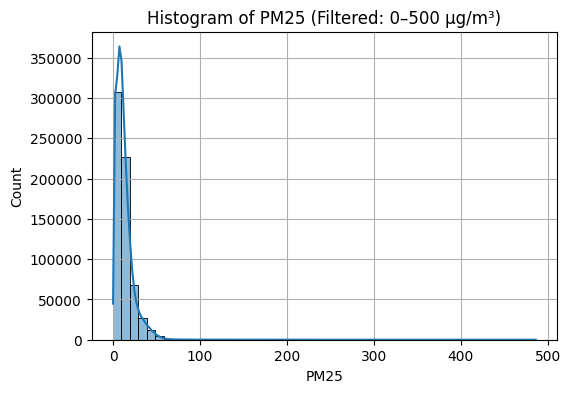

In [ ]:
plt.figure(figsize=(6, 4))
filtered_PM25 = data_all["PM25"].dropna()
filtered_PM25 = filtered_PM25[(filtered_PM25 >= 0) & (filtered_PM25 <= 500)]  # Adjust if needed

sns.histplot(filtered_PM25, bins=50, kde=True)
plt.title("Histogram of PM25 (Filtered: 0–500 µg/m³)")
plt.xlabel("PM25")
plt.grid(True)
plt.show()

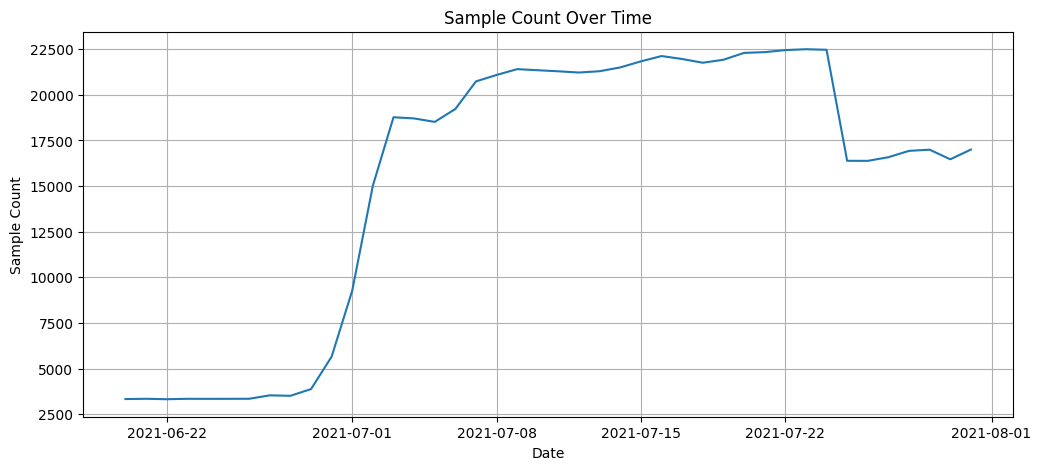

In [ ]:
# STEP 25: Time vs Sample Count
sample_over_time = data_all.groupby(data_all['ReadingDateTimeUTC'].dt.date).size()

plt.figure(figsize=(12, 5))
sample_over_time.plot()
plt.title("Sample Count Over Time")
plt.xlabel("Date")
plt.ylabel("Sample Count")
plt.grid(True)
plt.show()

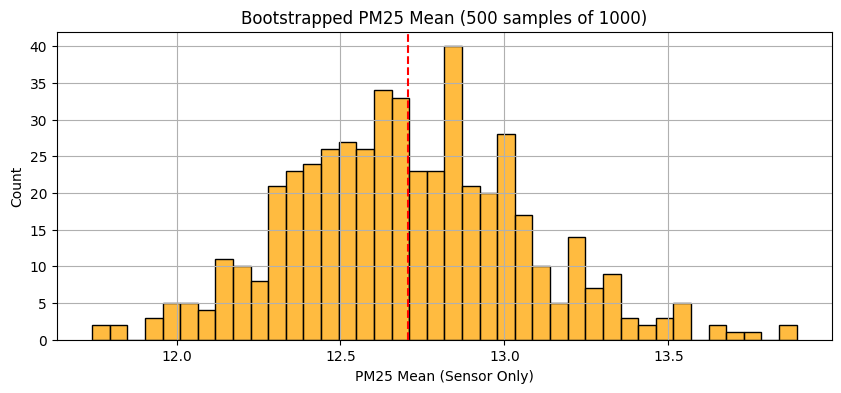

In [ ]:
# STEP 26: Bootstrapping Mean PM10 (from data_all, filtered)
boot_means = [
    resample(
        data_all["PM25"][(data_all["PM25"] >= 0) & (data_all["PM25"] <= 500)].dropna(),
        n_samples=1000
    ).mean()
    for _ in range(500)
]

plt.figure(figsize=(10, 4))
sns.histplot(boot_means, bins=40, color='orange')
plt.axvline(np.mean(boot_means), color='red', linestyle='--')
plt.title("Bootstrapped PM25 Mean (500 samples of 1000)")
plt.xlabel("PM25 Mean (Sensor Only)")
plt.grid(True)
plt.show()

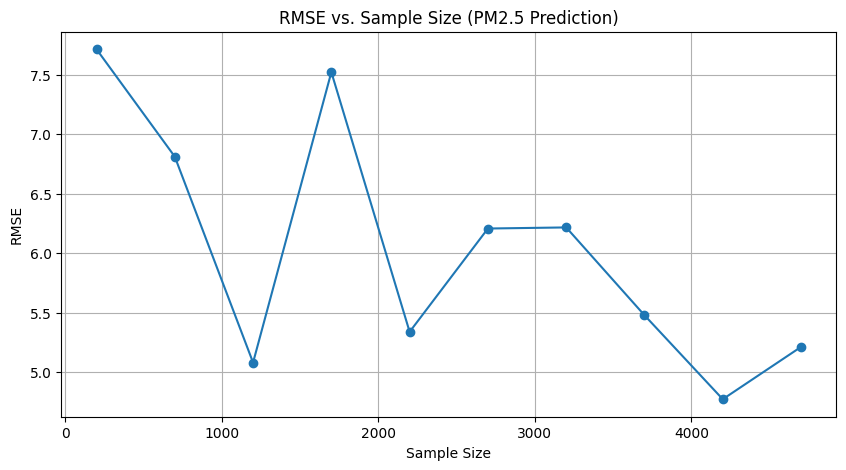

In [ ]:
# STEP 27: RMSE vs. Sample Size (PM2.5 Prediction)
samples = list(range(200, min(5000, len(data_all)), 500))
rmses = []

for size in samples:
    sample = data_all.sample(n=size)
    X = sample[["PM25"]].fillna(0)
    y = sample["CalibratedPM25"].fillna(0)
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    rmses.append(rmse)

plt.figure(figsize=(10, 5))
plt.plot(samples, rmses, marker='o')
plt.title("RMSE vs. Sample Size (PM2.5 Prediction)")
plt.xlabel("Sample Size")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

In [ ]:
# STEP 28: Summary Statistics
summary_stats = data_all[["PM25", "CalibratedPM25"]].describe().T[["mean", "std", "min", "max"]]
summary_stats.loc["PM25"] = data_all["PM25"][(data_all["PM25"] >= 0) & (data_all["PM25"] <= 500)].describe()[["mean", "std", "min", "max"]]

print("Summary Statistics:")
display(summary_stats)

Summary Statistics:


,mean,std,min,max
PM25,12.725451,10.790649,0.00,486.344513
CalibratedPM25,14.347587,9.581892,2.64,244.580000


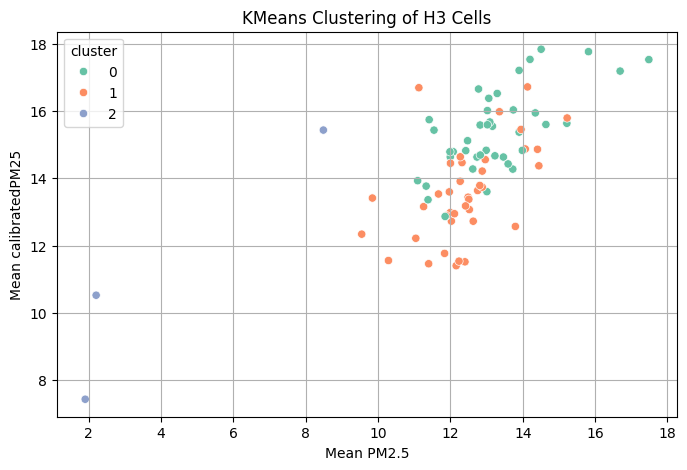

Cluster Profiles:


,pm25_mean,calibratedPM25_mean,calibratedO3_mean,calibratedNO2_mean,co_mean,batteryLevel_mean,temp_mean,humidity_mean,cellSignal_mean,cluster
0,13.260905,15.390292,32.066405,10.071291,0.337616,4.149128,26.943804,62.325074,-82.219337,0
1,12.407674,13.575568,32.012437,8.350961,-0.107146,4.038277,25.735133,66.864919,-90.018236,1
2,4.198345,11.129293,25.319869,13.816443,0.549442,3.887603,22.149609,59.164509,-94.531102,2


In [ ]:
# STEP 29: KMeans Clustering (on valid PM sensor data only)

# Recalculate H3 on data_all to ensure consistency
data_all["h3"] = data_all.apply(lambda row: h3.geo_to_h3(row["Latitude"], row["Longitude"], 9), axis=1)

# Aggregate by H3 using only valid PM10 range
agg_by_h3 = data_all.groupby("h3").agg({
    "PM25": "mean",
    "CalibratedPM25": lambda x: x[(x >= 0) & (x <= 500)].mean(),
    "CalibratedO3": "mean",
    "CalibratedNO2": "mean",
    "CO": "mean",
    "BatteryLevel": "mean",
    "Temperature": "mean",
    "Humidity": "mean",
    "CellSignal": "mean"
}).reset_index()

agg_by_h3.columns = ["h3", "pm25_mean", "calibratedPM25_mean", "calibratedO3_mean", "calibratedNO2_mean", "co_mean", "batteryLevel_mean", "temp_mean", "humidity_mean", "cellSignal_mean"]

# Filter out NaNs before clustering
features = ["pm25_mean", "calibratedPM25_mean", 'calibratedO3_mean', 'calibratedNO2_mean', 'co_mean', 'batteryLevel_mean', 'temp_mean', 'humidity_mean', 'cellSignal_mean']
X = agg_by_h3[features].dropna().reset_index(drop=True)
X_scaled = StandardScaler().fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Create clustered DataFrame
agg_clustered = agg_by_h3.dropna(subset=features).reset_index(drop=True)
agg_clustered["cluster"] = cluster_labels

# Visualize clusters
plt.figure(figsize=(8, 5))
# Use "calibratedPM25_mean" for the y-axis to match the aggregation
sns.scatterplot(data=agg_clustered, x="pm25_mean", y="calibratedPM25_mean", hue="cluster", palette="Set2")
plt.title("KMeans Clustering of H3 Cells")
plt.xlabel("Mean PM2.5")
plt.ylabel("Mean calibratedPM25")
plt.grid(True)
plt.show()

# Show cluster centers
cluster_centers = pd.DataFrame(StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_), columns=features)
cluster_centers["cluster"] = range(3)
print("Cluster Profiles:")
display(cluster_centers)

In [ ]:
# STEP 30: Multivariate Regression
df = data_all[["PM25", "CalibratedPM25", "CalibratedO3", "CalibratedNO2", "CO", "BatteryLevel", "Temperature", "Humidity", "CellSignal"]].dropna()
df = df[(df["PM25"] >= 0) & (df["PM25"] <= 500)]

X_reg = sm.add_constant(df[["CalibratedPM25", "CalibratedO3", "CalibratedNO2", "CO", "BatteryLevel", "Temperature", "Humidity", "CellSignal"]])
y_reg = df["PM25"]

model = sm.OLS(y_reg, X_reg).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   PM25   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                 2.069e+05
Date:                Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                        07:49:47   Log-Likelihood:            -1.9335e+06
No. Observations:              613366   AIC:                         3.867e+06
Df Residuals:                  613357   BIC:                         3.867e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -28.2300      0.154   -183.

In [ ]:
# STEP 31: Save for Comparison
summary_stats = df.describe()[["PM25", "CalibratedPM25"]].T[["mean", "std", "min", "max"]]
summary_stats["City"] = "Chicago"
agg_clustered["City"] = "Chicago"

summary_stats.to_csv("Chicago_summary_stats.csv", index=True)
agg_clustered.to_csv("Chicago_aggregated_h3.csv", index=False)

print(" Chicago analysis complete and saved.")

 Chicago analysis complete and saved.


#Boston Datasets

In [4]:
# STEP 1: Load Boston Data

from google.colab import files
uploaded = files.upload()

boston_df = pd.read_csv("Boston_PM_NO2.csv")
print("Boston columns:", boston_df.columns)
print("Shape:", boston_df.shape)
boston_df.head()

Saving boston.geojson to boston.geojson
Saving Boston_PM_NO2.csv to Boston_PM_NO2.csv
Boston columns: Index(['SensorID', 'time', 'latitude', 'longitude', 'bin0', 'bin1', 'bin10',
       'bin11', 'bin12', 'bin13', 'bin14', 'bin15', 'bin16', 'bin17', 'bin18',
       'bin19', 'bin2', 'bin20', 'bin21', 'bin22', 'bin23', 'bin3', 'bin4',
       'bin5', 'bin6', 'bin7', 'bin8', 'bin9', 'humidity', 'temperature',
       'pm25', 'no2'],
      dtype='object')
Shape: (122768, 32)


,SensorID,time,latitude,longitude,bin0,bin1,bin10,bin11,bin12,bin13,...,bin4,bin5,bin6,bin7,bin8,bin9,humidity,temperature,pm25,no2
0,Boston_CS01A,1644587952,42.406059,-71.116470,85,8,0,1,0,0,...,0,0,0,0,0,0,45.8,8.7,2.215319,14.917748
1,Boston_CS01A,1644587957,42.406059,-71.116470,87,5,0,0,0,0,...,1,0,0,0,0,0,45.7,8.7,2.242558,14.917748
2,Boston_CS01A,1644587962,42.406059,-71.116478,89,10,0,0,0,0,...,1,1,0,0,0,0,45.6,8.7,2.243146,14.917748
3,Boston_CS01A,1644587967,42.406059,-71.116486,113,10,0,0,0,0,...,0,1,0,0,0,0,45.5,8.7,2.242699,14.917748
4,Boston_CS01A,1644587972,42.406063,-71.116501,73,8,0,0,0,0,...,0,1,0,0,0,0,45.5,8.8,1.996889,14.917748


In [5]:
# STEP 2: Time conversion
boston_df["datetime"] = pd.to_datetime(boston_df["time"], unit="s")

# STEP 3: Apply H3 Geohash
boston_df["h3"] = boston_df.apply(lambda row: h3.geo_to_h3(row["latitude"], row["longitude"], 9), axis=1)

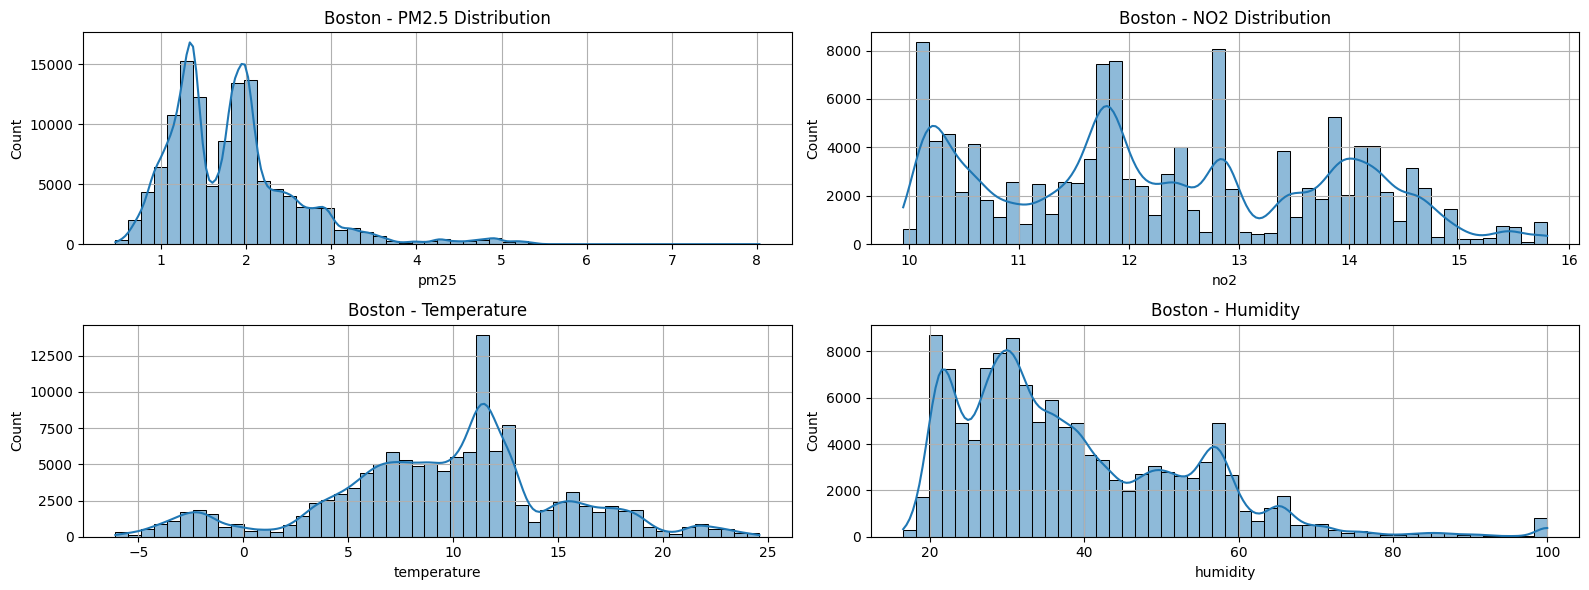

In [6]:
# STEP 4: EDA - Histograms for Boston
plt.figure(figsize=(16, 6))

# PM2.5
plt.subplot(2, 2, 1)
sns.histplot(boston_df["pm25"].dropna(), bins=50, kde=True)
plt.title("Boston - PM2.5 Distribution")
plt.grid(True)

# NO2
plt.subplot(2, 2, 2)
sns.histplot(boston_df["no2"].dropna(), bins=50, kde=True)
plt.title("Boston - NO2 Distribution")
plt.grid(True)

# Temperature
plt.subplot(2, 2, 3)
sns.histplot(boston_df["temperature"].dropna(), bins=50, kde=True)
plt.title("Boston - Temperature")
plt.grid(True)

# Humidity
plt.subplot(2, 2, 4)
sns.histplot(boston_df["humidity"].dropna(), bins=50, kde=True)
plt.title("Boston - Humidity")
plt.grid(True)

plt.tight_layout()
plt.show()

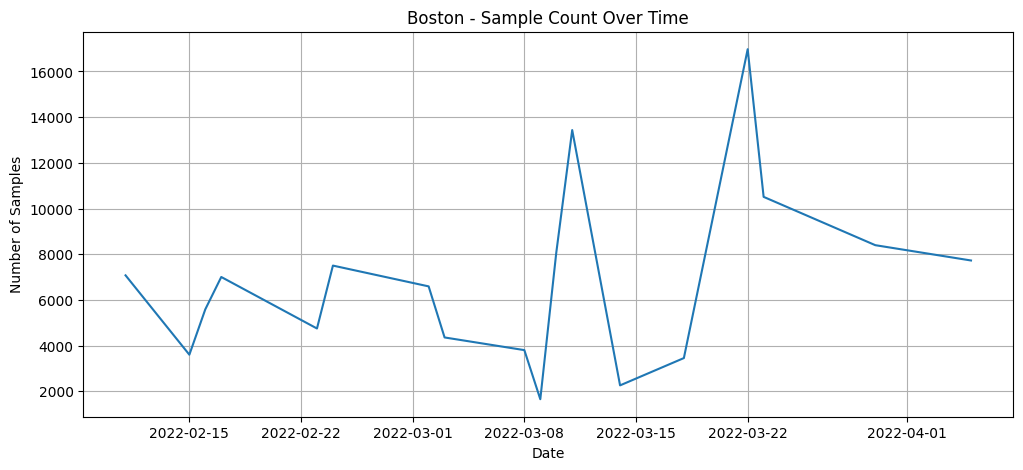

In [7]:
# STEP 5: Time vs. Sample Count
samples_boston = boston_df.groupby(boston_df['datetime'].dt.date).size()

plt.figure(figsize=(12, 5))
samples_boston.plot()
plt.title("Boston - Sample Count Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

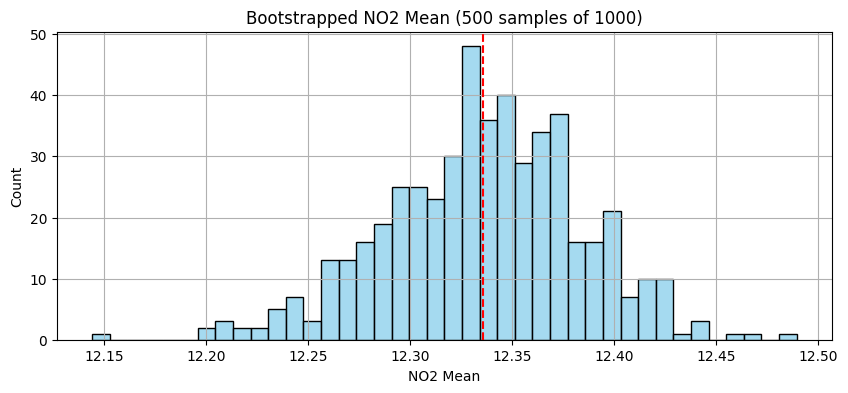

In [8]:
# STEP 6: Bootstrapping - Mean NO2
boot_means_no2 = [
    resample(boston_df["no2"].dropna(), n_samples=1000).mean()
    for _ in range(500)
]

plt.figure(figsize=(10, 4))
sns.histplot(boot_means_no2, bins=40, color='skyblue')
plt.axvline(np.mean(boot_means_no2), color='red', linestyle='--')
plt.title("Bootstrapped NO2 Mean (500 samples of 1000)")
plt.xlabel("NO2 Mean")
plt.grid(True)
plt.show()

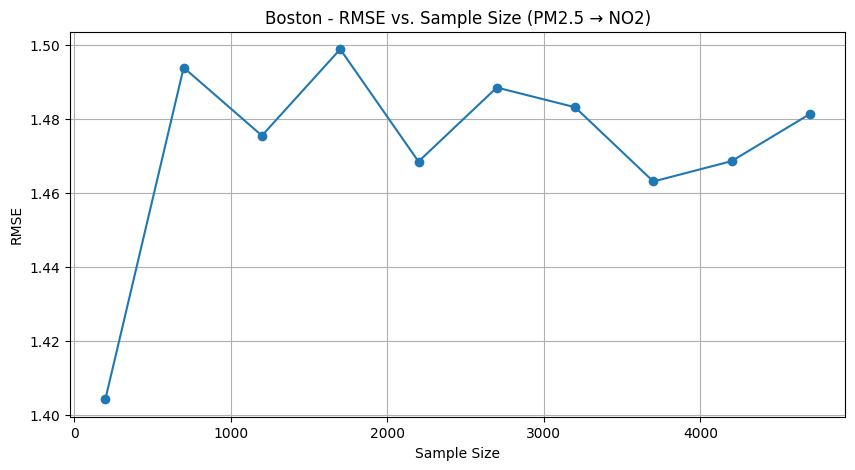

In [9]:
# STEP 7: RMSE vs Sample Size
samples = list(range(200, min(5000, len(boston_df)), 500))
rmses_boston = []

for size in samples:
    sample = boston_df.sample(n=size)
    X = sample[["pm25"]].fillna(0)
    y = sample["no2"].fillna(0)
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    rmses_boston.append(rmse)

plt.figure(figsize=(10, 5))
plt.plot(samples, rmses_boston, marker='o')
plt.title("Boston - RMSE vs. Sample Size (PM2.5 → NO2)")
plt.xlabel("Sample Size")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

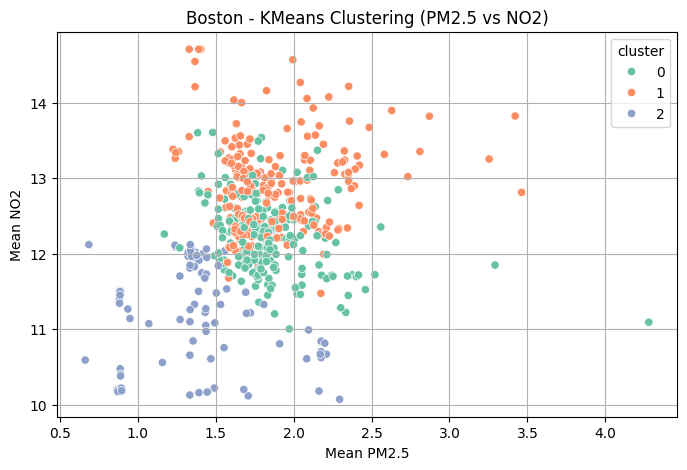

In [10]:
# STEP 8: Clustering - Aggregate by H3
agg_boston = boston_df.groupby("h3").agg({
    "pm25": "mean",
    "no2": "mean",
    "temperature": "mean",
    "humidity": "mean"
}).reset_index()
agg_boston.columns = ["h3", "pm25_mean", "no2_mean", "temp_mean", "humidity_mean"]

# Clustering
features = ["pm25_mean", "no2_mean", "temp_mean", "humidity_mean"]
X = agg_boston[features].dropna().reset_index(drop=True)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
agg_clustered_boston = agg_boston.dropna(subset=features).reset_index(drop=True)
agg_clustered_boston["cluster"] = kmeans.fit_predict(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=agg_clustered_boston, x="pm25_mean", y="no2_mean", hue="cluster", palette="Set2")
plt.title("Boston - KMeans Clustering (PM2.5 vs NO2)")
plt.xlabel("Mean PM2.5")
plt.ylabel("Mean NO2")
plt.grid(True)
plt.show()

In [11]:
# STEP 9: Regression
df_boston = boston_df[["no2", "pm25", "temperature", "humidity"]].dropna()
X_reg_boston = sm.add_constant(df_boston[["pm25", "temperature", "humidity"]])
y_reg_boston = df_boston["no2"]

model_boston = sm.OLS(y_reg_boston, X_reg_boston).fit()
print(model_boston.summary())

                            OLS Regression Results                            
Dep. Variable:                    no2   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                 2.651e+04
Date:                Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                        12:07:50   Log-Likelihood:            -1.9359e+05
No. Observations:              122768   AIC:                         3.872e+05
Df Residuals:                  122764   BIC:                         3.872e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          10.6383      0.013    819.520      

In [12]:
# STEP 10: Save Summary Stats + Clustering
summary_boston = df_boston.describe()[["pm25", "no2"]].T[["mean", "std", "min", "max"]]
summary_boston["city"] = "Boston"
agg_clustered_boston["city"] = "Boston"

summary_boston.to_csv("boston_summary_stats.csv")
agg_clustered_boston.to_csv("boston_aggregated_h3.csv", index=False)

print("Boston analysis complete and saved.")

Boston analysis complete and saved.


# Cross-City Comparison